In [1]:
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.model_evaluation import evaluar_modelo_de_clasificacion
from src.model_training import construir_pipeline_clasificacion
from sklearn.model_selection import train_test_split
from src.Routes import RUTAS



In [2]:
path_archivo_codificado = RUTAS['data_processed'] / 'Sales_Marketing_Clean_(Codificado).csv'

df_cod = pd.read_csv(path_archivo_codificado)
df_cod.head()

,age,total_spent,avg_order_value,lifetime_value,last_3_month_purchase_freq,marketing_spend_per_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,support_tickets,delivery_delay_days,satisfaction_score,nps_score,gender,country,acquisition_channel,subscription_type,payment_method
0,35,559.525,65.247,915.311,14,27.56,7,13.904,5.415,0.67,0.26,0,3,3.0,10,1,2,0,0,4
1,35,356.491,48.474,2079.961,11,15.15,19,5.113,5.352,0.70,0.37,5,3,3.0,7,3,1,3,1,0
2,27,689.332,77.815,1379.151,9,13.51,18,9.743,3.595,0.47,0.44,1,2,5.0,6,0,1,0,0,4
3,36,445.430,71.712,774.653,7,25.65,16,9.643,2.950,0.58,0.37,0,2,4.0,6,0,2,1,0,2
4,29,686.286,44.990,87.680,11,12.39,12,7.791,2.406,0.05,0.16,2,4,3.0,1,1,5,4,1,0


In [3]:
nombre_target = 'subscription_type'
y = df_cod[nombre_target]
X = df_cod.drop(columns=[nombre_target], errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Entrenando modelo Random Forest...')
pipeline_rf = construir_pipeline_clasificacion(tipo_de_modelo='rf')
pipeline_rf.fit(X_train, y_train)

print('Entrenando modelo Regresión Logistica...')
pipeline_lr = construir_pipeline_clasificacion(tipo_de_modelo='lr')
pipeline_lr.fit(X_train, y_train)

print('Modelos entrenados exitosamente')

Entrenando modelo Random Forest...
Entrenando modelo Regresión Logistica...
Modelos entrenados exitosamente



EVALUACIÓN DEL MODELO: RANDOM FOREST

1. Validación Cruzada (Accuracy de 5 Folds):
   Scores: [0.56071429 0.57142857 0.55912698 0.55992063 0.57579365]
   Media: 0.5654 (+/- 0.0069)

2. Reporte de Clasificación en Set de Prueba:
              precision    recall  f1-score   support

           0       0.57      0.54      0.55      1544
           1       0.58      0.60      0.59      1606

    accuracy                           0.57      3150
   macro avg       0.57      0.57      0.57      3150
weighted avg       0.57      0.57      0.57      3150



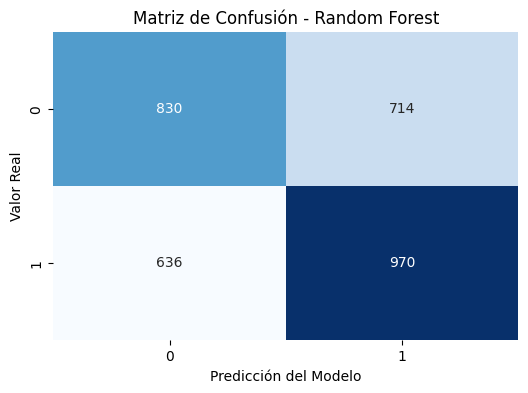


3. ROC-AUC Score: 0.6262
--------------------------------------------------


In [4]:
evaluar_modelo_de_clasificacion(pipeline_rf, X_train, y_train, X_test, y_test, "Random Forest")

El modelo **Random Forest** muestra un desempeño superior al azar, con un **ROC-AUC de 0.6262** y una media de validación cruzada de **0.5654 ± 0.0069**. Estos valores indican una capacidad discriminatoria moderada y una estabilidad aceptable entre particiones, aunque todavía lejos de un nivel de precisión alto para toma de decisiones críticas.

La matriz de confusión y los indicadores por clase muestran un comportamiento relativamente balanceado (**F1 de 0.55 y 0.59**), con mejor identificación de clientes que sí convierten. Sin embargo, el número de falsos positivos sigue siendo relevante (**714 casos**), lo que sugiere margen de mejora en calibración y ajuste de umbral.

**Conclusiones**

El resultado confirma que el fenómeno de suscripción contiene relaciones no lineales que un modelo basado en árboles puede capturar mejor que un enfoque lineal simple. Aun así, el rendimiento actual sugiere que el modelo está en una fase intermedia de madurez predictiva.

Como siguiente paso, conviene profundizar en el tuning de hiperparámetros del bosque, revisar importancia de variables y evaluar calibración de probabilidades para reducir falsos positivos sin perder capacidad de detección.


EVALUACIÓN DEL MODELO: REGRESIÓN LOGÍSTICA

1. Validación Cruzada (Accuracy de 5 Folds):
   Scores: [0.51706349 0.48769841 0.51309524 0.49087302 0.50714286]
   Media: 0.5032 (+/- 0.0118)

2. Reporte de Clasificación en Set de Prueba:
              precision    recall  f1-score   support

           0       0.50      0.30      0.38      1544
           1       0.51      0.71      0.60      1606

    accuracy                           0.51      3150
   macro avg       0.51      0.51      0.49      3150
weighted avg       0.51      0.51      0.49      3150



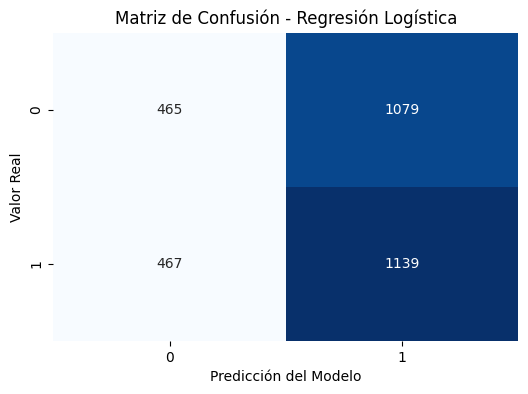


3. ROC-AUC Score: 0.5058
--------------------------------------------------


In [5]:
evaluar_modelo_de_clasificacion(pipeline_lr, X_train, y_train, X_test, y_test, "Regresión Logística")

La **Regresión Logística** presenta un rendimiento prácticamente equivalente al azar, con **ROC-AUC de 0.5058** y promedio de validación cercano a **0.5032**. Este patrón sugiere que el modelo no está encontrando una frontera de separación robusta para distinguir entre las clases objetivo.

En la matriz de confusión se observa una tendencia a sobrepredecir la clase positiva, lo que produce un **Recall alto (0.71)** pero con **Precision baja (0.51)**. Operativamente, esto implica que el modelo detecta muchos casos potenciales, pero con una proporción elevada de clasificaciones no confiables.

**Conclusiones**

La evidencia apunta a que la estructura del problema no es predominantemente lineal y que las interacciones entre variables superan la capacidad explicativa de un modelo lineal base. En este contexto, la regresión logística funciona como línea base diagnóstica, pero no como alternativa competitiva actual.

Como siguiente paso, se recomienda mantener la regresión logística como benchmark e incorporar transformaciones de variables, interacciones explícitas y selección de atributos para evaluar si puede recuperar señal útil frente a modelos no lineales.

En la comparación directa de clasificación, **Random Forest** supera de forma consistente a **Regresión Logística** en capacidad de discriminación y estabilidad. El diferencial de desempeño confirma que el problema requiere modelar relaciones más complejas que las que captura una frontera lineal.

Desde una perspectiva de negocio, este comportamiento se traduce en una mejor priorización de clientes potenciales para estrategias de upselling cuando se utiliza el enfoque basado en árboles. Aun así, el rendimiento global todavía es moderado y exige optimización adicional antes de una adopción operativa plena.

**Conclusiones**

La clasificación en este dataset está influida por patrones no lineales e interacciones entre variables de comportamiento, por lo que los modelos de árboles constituyen la base metodológica más sólida en el estado actual del proyecto.

Como siguiente paso, corresponde ejecutar un tuning más profundo de Random Forest, complementar con ingeniería de características y comparar contra modelos ensamblados adicionales para consolidar mejoras en precisión, recall y robustez general.

## Evaluacion de modelos de regresion (total_spent)

En este bloque se implementan dos modelos base de regresion para predecir `total_spent`:
- `LinearRegression`
- `RandomForestRegressor`

Se evaluan con las metricas `RMSE` y `R²` para comparar desempeño.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

if 'df_cod' not in globals():
    df_cod = pd.read_csv(path_archivo_codificado)

target_reg = 'total_spent'
y_reg = df_cod[target_reg]
X_reg = df_cod.drop(columns=[target_reg], errors='ignore')

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

modelos_regresion = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}

resultados_reg = []

for nombre_modelo, modelo in modelos_regresion.items():
    modelo.fit(X_train_reg, y_train_reg)
    y_pred_reg = modelo.predict(X_test_reg)

    rmse = mean_squared_error(y_test_reg, y_pred_reg) ** 0.5
    r2 = r2_score(y_test_reg, y_pred_reg)

    resultados_reg.append({
        'Modelo': nombre_modelo,
        'RMSE': rmse,
        'R2': r2
    })

    print(f"\nModelo: {nombre_modelo}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}")

df_resultados_reg = pd.DataFrame(resultados_reg).sort_values(by='RMSE')
print('\nResumen de resultados de regresion:')
display(df_resultados_reg)


Modelo: LinearRegression
RMSE: 269.1598
R2: -0.0024

Modelo: RandomForestRegressor
RMSE: 262.2944
R2: 0.0481

Resumen de resultados de regresion:


,Modelo,RMSE,R2
1,RandomForestRegressor,262.294382,0.048086
0,LinearRegression,269.159787,-0.002398


En el bloque de regresión para `total_spent`, **RandomForestRegressor** obtiene el mejor desempeño con **RMSE de 262.29** frente a **269.16** de LinearRegression, lo que representa una mejora aproximada de **6.87** puntos de error. En ajuste global también supera al modelo lineal, con **R² de 0.0481** frente a **-0.0024**.

La diferencia entre modelos indica que la relación entre predictores y gasto total no se describe adecuadamente con un esquema estrictamente lineal. El enfoque basado en árboles captura mejor no linealidades e interacciones, aunque la capacidad explicativa total todavía se mantiene baja.

**Conclusiones**

El resultado posiciona a RandomForestRegressor como mejor baseline de regresión en esta etapa, pero el valor de R² cercano a cero confirma que el problema sigue subexplicado y depende de enriquecer el espacio de variables.

Como siguiente paso, se recomienda aplicar tuning específico para regresión (profundidad, mínimo de muestras por hoja y número de árboles), incorporar variables de comportamiento más informativas y validar mejoras con particiones adicionales para reforzar la robustez del modelo.